# AndinaLog 03B — EDA integrado didáctico

**Grupo 06, rol 03B.** Este análisis responde al mandato de proteger la cadena de frío, estudiar rotación/vencimiento del inventario y explorar señales para anticipar una desviación térmica en los próximos 60 minutos. Utiliza las cuatro salidas didácticas de tratamiento. No vuelve a modificar los CSV ni entrena un modelo.

**Granularidades:** IoT = lectura; Inventario = lote/movimiento; Productos = un producto; Flota = un camión. Los cruces con maestros deben ser muchos-a-uno. Para contar viajes con desviación se agregan lecturas **antes** de resumir por categoría y tipo de camión. Las variables temporales se calculan tras ordenar y agrupar por viaje.

**Observado frente a estimado:** la vista analítica puede incluir atributos inferidos, pero los indicadores principales de excursión y vencimiento observados excluyen temperaturas, umbrales o fechas imputados. Se muestran coberturas para que el lector sepa cuántas filas respaldan cada conclusión.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt=None
    print("Matplotlib no está instalado en este entorno; se muestran las tablas sin gráficos")

ENTORNO="auto"  # auto, local, drive
RUTA_PROYECTO_DRIVE="/content/drive/MyDrive/GIAD"
def encontrar_raiz():
    if ENTORNO=="drive" or (ENTORNO=="auto" and "google.colab" in sys.modules):
        from google.colab import drive
        drive.mount("/content/drive")
        return Path(RUTA_PROYECTO_DRIVE)
    for carpeta in [Path.cwd(),*Path.cwd().parents]:
        if (carpeta/"proyecto-integrador/02_tratamiento/andinalog_productos/salidas/andinalog_productos_didactico_v1_silver.csv").is_file():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz de practicasNotebookColab")

RAIZ=encontrar_raiz()
BASE=RAIZ/"proyecto-integrador/02_tratamiento"
RUTAS={
 "iot":BASE/"andinalog_iot_telemetry/salidas/andinalog_iot_telemetry_didactico_v1_tratado.csv",
 "productos":BASE/"andinalog_productos/salidas/andinalog_productos_didactico_v1_silver.csv",
 "flota":BASE/"andinalog_flota/salidas/andinalog_flota_didactico_v1_silver.csv",
 "inventario":BASE/"andinalog_inventory_tracking/salidas/andinalog_inventory_tracking_didactico_v1_silver.csv",
}
for nombre,ruta in RUTAS.items():
    if not ruta.is_file(): raise FileNotFoundError(f"Falta {nombre}: {ruta}")
tablas={n:pd.read_csv(p,dtype="string",encoding="utf-8-sig",keep_default_na=False)
        for n,p in RUTAS.items()}
iot,productos,flota,inv=[tablas[n] for n in ["iot","productos","flota","inventario"]]
assert productos["producto_id_tratado"].is_unique
assert flota["camion_id_tratado"].is_unique
assert inv["lote_id"].is_unique
assert iot["fila_bronze"].is_unique
print({nombre:len(tabla) for nombre,tabla in tablas.items()})


{'iot': 28677, 'productos': 60, 'flota': 30, 'inventario': 5980}


## 1. Auditoría de cobertura y vigencia del maestro

Los notebooks de IoT se ejecutaron antes del nuevo Silver de Productos. Por ello `apta_kpi_termico` del IoT tratado puede reflejar una cobertura antigua. Aquí se une el maestro nuevo por **claves tratadas**, se recalcula el desvío y se verifica la bandera. Esta operación es analítica y deja intactas las salidas de tratamiento.

El EDA comprueba que `apta_kpi_termico` del IoT tratado coincide con su cálculo observado usando Productos Silver actual. La alerta `posible_incompatibilidad_termica` se contrasta con Productos y Flota Silver; se conserva en el KPI y se resume por separado.


In [2]:
pcols=["producto_id_tratado","categoria_logistica_tratada",
 "temperatura_conservacion_requerida_c_tratada","tolerancia_temperatura_c_tratada",
 "categoria_imputada","temperatura_imputada","apto_umbral_termico_observado"]
fcols=["camion_id_tratado","tipo_camion_tratado","centro_distribucion_base_tratado"]
tel=iot.merge(productos[pcols],left_on="producto_id",right_on="producto_id_tratado",
              how="left",validate="many_to_one",indicator="_join_producto")
tel=tel.merge(flota[fcols],on="camion_id_tratado",how="left",validate="many_to_one",indicator="_join_flota")
assert len(tel)==len(iot)
inventario=inv.merge(productos[["producto_id_tratado","categoria_logistica_tratada","categoria_imputada"]],
                     on="producto_id_tratado",how="left",validate="many_to_one",indicator="_join_producto")
assert len(inventario)==len(inv)
cobertura=pd.DataFrame([
 ["IoT → Productos",len(tel),int(tel["_join_producto"].eq("both").sum())],
 ["IoT → Flota",len(tel),int(tel["_join_flota"].eq("both").sum())],
 ["Inventario → Productos",len(inventario),int(inventario["_join_producto"].eq("both").sum())],
],columns=["cruce","filas_origen","filas_con_match"])
cobertura["cobertura_pct"]=100*cobertura["filas_con_match"]/cobertura["filas_origen"]
display(cobertura)

tel["temp_c"]=pd.to_numeric(tel["temperatura_cabina_c_tratada"],errors="coerce")
tel["objetivo_c"]=pd.to_numeric(tel["temperatura_conservacion_requerida_c_tratada"],errors="coerce")
tel["tolerancia_c"]=pd.to_numeric(tel["tolerancia_temperatura_c_tratada"],errors="coerce")
tel["desvio_respecto_umbral_c"]=(tel["temp_c"]-tel["objetivo_c"]).abs()-tel["tolerancia_c"]
tel["excursion_calculada"]=tel["desvio_respecto_umbral_c"].gt(0)
tel["flag_actual"] = tel["desviacion_termica_flag"].eq("1")
tel["flag_60min"] = tel["desviacion_proximos_60min_flag"].eq("1")
tel["flag_coherente_actual"]=(tel["excursion_calculada"]==tel["flag_actual"])
tel["umbral_observado"]=tel["apto_umbral_termico_observado"].eq("True")
tel["temperatura_observada"]=tel["temperatura_imputada_x"].eq("False") if "temperatura_imputada_x" in tel else tel["temperatura_imputada"].eq("False")
tel["lectura_termica_observada"]=(tel["temperatura_observada"] & tel["umbral_observado"] &
                                   tel["flag_coherente_actual"] & tel["temp_c"].notna())
assert tel["_join_producto"].eq("both").all() and tel["_join_flota"].eq("both").all()
assert inventario["_join_producto"].eq("both").all()
assert tel["flag_coherente_actual"].all()
assert tel["apta_kpi_termico"].eq(tel["lectura_termica_observada"].astype(str)).all(), "Tratamiento y EDA discrepan en apta_kpi_termico"
assert tel["tipo_camion_maestro"].eq(tel["tipo_camion_tratado"]).all(), "Tipo de camión difiere de Flota Silver"
compat_esperada=tel["categoria_imputada"].eq("False") & tel["categoria_logistica_tratada"].isin(["Fresco","Congelado"]) & tel["tipo_camion_tratado"].eq("Seco")
assert tel["posible_incompatibilidad_termica"].eq(compat_esperada.astype(str)).all(), "Marca de compatibilidad no coincide con maestros"
print("IoT apta_kpi_termico guardada:",int(iot["apta_kpi_termico"].eq("True").sum()))
print("Lecturas térmicas observadas con maestro actual:",int(tel["lectura_termica_observada"].sum()))
print("Filas con umbral de producto inferido:",int((~tel["umbral_observado"]).sum()))
print("Viajes con posible incompatibilidad:",tel.loc[tel["posible_incompatibilidad_termica"].eq("True"),"viaje_id"].nunique())


,cruce,filas_origen,filas_con_match,cobertura_pct
0,IoT → Productos,28677,28677,100.0
1,IoT → Flota,28677,28677,100.0
2,Inventario → Productos,5980,5980,100.0


IoT apta_kpi_termico guardada: 26183
Lecturas térmicas observadas con maestro actual: 26183
Filas con umbral de producto inferido: 2389
Viajes con posible incompatibilidad: 17


## 2. Vista de cada fuente

Se muestran distribuciones necesarias para interpretar las tres evidencias: categorías y umbrales de Productos; tipo/capacidad de Flota; permanencia, merma y vencimiento en Inventario; cobertura temporal y banderas de IoT. Los conteos son de las salidas tratadas, no de Bronze.


PRODUCTOS por categoría y origen del umbral


,categoria_logistica_tratada,apto_umbral_termico_observado,productos
0,Congelado,True,10
1,Fresco,False,3
2,Fresco,True,17
3,Seco,False,2
4,Seco,True,28


FLOTA por tipo


,tipo_camion_tratado,camiones,capacidad_mediana_kg
0,Refrigerado,14,5000.0
1,Seco,16,8000.0


INVENTARIO: vencimientos observados e imputados


,vencimiento_imputado,lotes
0,False,5962
1,True,18


IoT: lecturas por viaje


,lecturas_por_viaje
count,1200.000000
mean,23.897500
std,0.314234
min,22.000000
25%,24.000000
50%,24.000000
75%,24.000000
max,24.000000


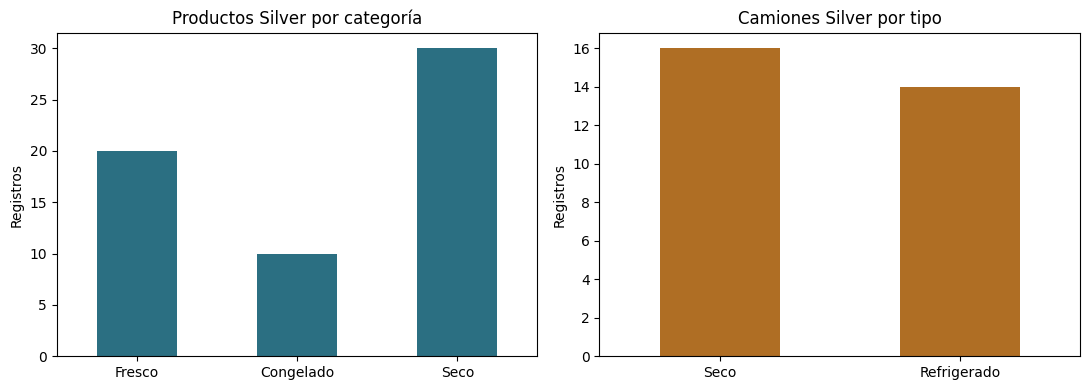

In [3]:
print("PRODUCTOS por categoría y origen del umbral")
display(productos.groupby(["categoria_logistica_tratada","apto_umbral_termico_observado"]).size().rename("productos").reset_index())
print("FLOTA por tipo")
display(flota.groupby("tipo_camion_tratado").agg(camiones=("camion_id_tratado","size"),
    capacidad_mediana_kg=("capacidad_kg_tratada",lambda s:pd.to_numeric(s).median())).reset_index())
print("INVENTARIO: vencimientos observados e imputados")
display(inv["vencimiento_imputado"].value_counts().rename_axis("vencimiento_imputado").reset_index(name="lotes"))
print("IoT: lecturas por viaje")
display(iot.groupby("viaje_id").size().describe().to_frame("lecturas_por_viaje"))

if plt is not None:
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    productos["categoria_logistica_tratada"].value_counts().reindex(["Fresco","Congelado","Seco"]).plot.bar(
        ax=axes[0],color="#2b6f82",title="Productos Silver por categoría")
    flota["tipo_camion_tratado"].value_counts().plot.bar(ax=axes[1],color="#af6e24",title="Camiones Silver por tipo")
    for ax in axes: ax.set_xlabel("");ax.set_ylabel("Registros");ax.tick_params(axis="x",rotation=0)
    fig.tight_layout();plt.show()


## 3. Evidencia 1 — excursiones térmicas por viaje

La población principal son lecturas con temperatura **observada**, umbral de producto **observado** y bandera coherente. Se agregan por `(viaje_id, order_id, camion_id_tratado, producto_id)` antes de calcular el porcentaje de viajes con desviación. Se informa la cobertura excluida por imputaciones. La versión analítica completa puede explorar las demás lecturas, pero no se mezcla con este indicador observado.


Viajes totales: 1200 | Viajes con al menos una lectura observada: 1100
Viajes observados con desviación: 311


,categoria_logistica,tipo_camion,viajes,lecturas,temperatura_promedio_c,lecturas_con_desviacion,pct_viajes_con_desviacion
0,Congelado,Refrigerado,203,4825,-17.73,220,37.44
1,Congelado,Seco,9,214,-17.16,30,88.89
2,Fresco,Refrigerado,313,7452,4.24,375,38.34
3,Fresco,Seco,8,191,5.14,36,87.5
4,Seco,Refrigerado,291,6923,20.08,100,18.9
5,Seco,Seco,276,6578,20.06,79,16.3


Viajes térmicos observados con posible incompatibilidad: 17
Resumen por alerta de compatibilidad (mismos viajes del KPI):


,posible_incompatibilidad,viajes,lecturas,viajes_con_desviacion,pct_viajes_con_desviacion
0,False,1083,25778,296,27.33
1,True,17,405,15,88.24


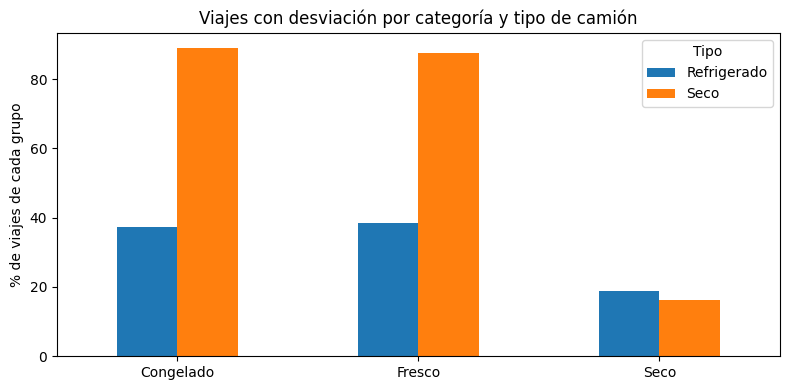

In [4]:
tel_obs=tel.loc[tel["lectura_termica_observada"]].copy()
viaje=tel_obs.groupby(["viaje_id","order_id","camion_id_tratado","producto_id"],as_index=False).agg(
    n_lecturas=("fila_bronze","size"),temperatura_promedio_c=("temp_c","mean"),
    n_desviaciones=("excursion_calculada","sum"),
    categoria_logistica=("categoria_logistica_tratada","first"),
    tipo_camion=("tipo_camion_tratado","first"),
    posible_incompatibilidad=("posible_incompatibilidad_termica",lambda x:x.eq("True").any()))
viaje["tuvo_desviacion"]=viaje["n_desviaciones"].gt(0)
assert viaje["viaje_id"].is_unique
resumen_viaje=viaje.groupby(["categoria_logistica","tipo_camion"],as_index=False).agg(
    viajes=("viaje_id","size"),lecturas=("n_lecturas","sum"),
    temperatura_promedio_c=("temperatura_promedio_c","mean"),
    lecturas_con_desviacion=("n_desviaciones","sum"),
    pct_viajes_con_desviacion=("tuvo_desviacion",lambda s:100*s.mean()))
print("Viajes totales:",iot["viaje_id"].nunique(),"| Viajes con al menos una lectura observada:",len(viaje))
print("Viajes observados con desviación:",int(viaje["tuvo_desviacion"].sum()))
display(resumen_viaje.round(2))
print("Viajes térmicos observados con posible incompatibilidad:",int(viaje["posible_incompatibilidad"].sum()))
print("Resumen por alerta de compatibilidad (mismos viajes del KPI):")
display(viaje.groupby("posible_incompatibilidad",as_index=False).agg(
    viajes=("viaje_id","size"),lecturas=("n_lecturas","sum"),
    viajes_con_desviacion=("tuvo_desviacion","sum"),
    pct_viajes_con_desviacion=("tuvo_desviacion",lambda x:100*x.mean())).round(2))

if plt is not None:
    fig,ax=plt.subplots(figsize=(8,4))
    resumen_viaje.pivot(index="categoria_logistica",columns="tipo_camion",values="pct_viajes_con_desviacion").plot.bar(ax=ax)
    ax.set_title("Viajes con desviación por categoría y tipo de camión")
    ax.set_ylabel("% de viajes de cada grupo");ax.set_xlabel("");ax.legend(title="Tipo")
    ax.tick_params(axis="x",rotation=0);fig.tight_layout();plt.show()


## 4. Evidencia 2 — riesgo de vencimiento y merma

La fecha de salida vacía representa un lote aún en almacén. En esta versión no hay casos así, pero el cálculo lo admite. `días para vencer al salir = vencimiento − salida` evita interpretar una fecha vencida como defecto de formato. Para el resumen **observado** se excluyen fechas de vencimiento y categorías imputadas. Las unidades de merma son unidades de inventario declaradas; no se traducen a kg ni se presupone una presentación física común entre productos.


Lotes Silver: 5980 | Lotes con vencimiento observado y categoría observada: 5673
Vencimientos imputados: 18 | Categoría inferida: 289


,categoria_logistica_tratada,lotes,merma_unidades_registradas,dias_promedio_almacen,mediana_merma_pct_lote,mediana_dias_para_vencer_al_salir,lotes_aun_en_almacen,lotes_salida_post_vencimiento
0,Congelado,1039,7644,13.6,1.4,169.0,0,0
1,Fresco,1784,30900,13.3,2.9,7.0,0,425
2,Seco,2850,11018,21.1,0.7,346.0,0,0


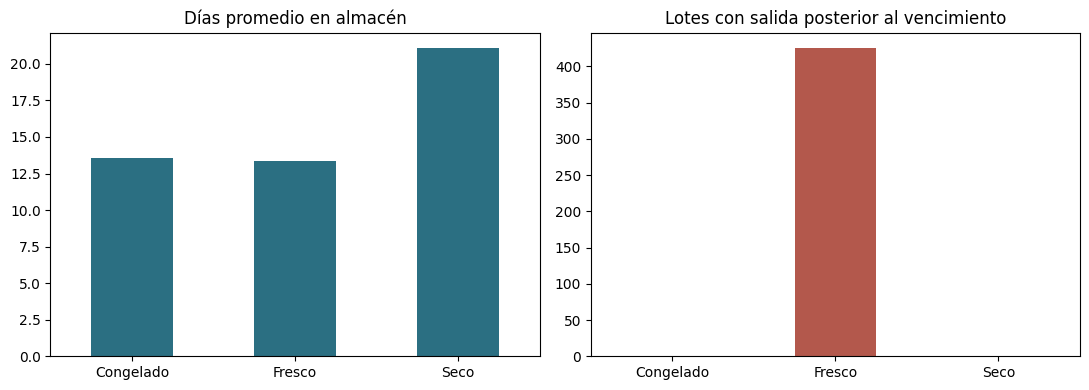

In [5]:
inventario["ingreso_fecha"]=pd.to_datetime(inventario["fecha_ingreso_tratada"],errors="coerce")
inventario["salida_fecha"]=pd.to_datetime(inventario["fecha_salida_tratada"],errors="coerce")
inventario["vencimiento_fecha"]=pd.to_datetime(inventario["fecha_vencimiento_tratada"],errors="coerce")
inventario["aun_en_almacen"]=inventario["salida_fecha"].isna()
inventario["dias_para_vencer_al_salir"]=(inventario["vencimiento_fecha"]-inventario["salida_fecha"]).dt.days
inventario["merma_unidades"]=pd.to_numeric(inventario["cantidad_merma_tratada"],errors="coerce")
inventario["ingreso_unidades"]=pd.to_numeric(inventario["cantidad_ingreso_tratada"],errors="coerce")
inventario["merma_pct_lote"]=100*inventario["merma_unidades"]/inventario["ingreso_unidades"]
inventario["dias_almacen"]=pd.to_numeric(inventario["dias_en_almacen_tratada"],errors="coerce")
inventario["vencimiento_observado"]=inventario["vencimiento_imputado"].eq("False")
inventario["categoria_observada"]=inventario["categoria_imputada"].eq("False")
inv_obs=inventario.loc[inventario["vencimiento_observado"] & inventario["categoria_observada"]].copy()
resumen_inventario=inv_obs.groupby("categoria_logistica_tratada",as_index=False).agg(
    lotes=("lote_id","size"),merma_unidades_registradas=("merma_unidades","sum"),
    dias_promedio_almacen=("dias_almacen","mean"),
    mediana_merma_pct_lote=("merma_pct_lote","median"),
    mediana_dias_para_vencer_al_salir=("dias_para_vencer_al_salir","median"),
    lotes_aun_en_almacen=("aun_en_almacen","sum"),
    lotes_salida_post_vencimiento=("riesgo_salida_post_vencimiento",lambda s:s.eq("True").sum()))
print("Lotes Silver:",len(inventario),"| Lotes con vencimiento observado y categoría observada:",len(inv_obs))
print("Vencimientos imputados:",int((~inventario["vencimiento_observado"]).sum()),
      "| Categoría inferida:",int((~inventario["categoria_observada"]).sum()))
display(resumen_inventario.round(1))

if plt is not None:
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    resumen_inventario.set_index("categoria_logistica_tratada")["dias_promedio_almacen"].plot.bar(
        ax=axes[0],color="#2b6f82",title="Días promedio en almacén")
    resumen_inventario.set_index("categoria_logistica_tratada")["lotes_salida_post_vencimiento"].plot.bar(
        ax=axes[1],color="#b3584c",title="Lotes con salida posterior al vencimiento")
    for ax in axes: ax.set_xlabel("");ax.tick_params(axis="x",rotation=0)
    fig.tight_layout();plt.show()


## 5. Evidencia 3 — variables para alerta de 60 minutos

Se ordena por `(viaje_id, timestamp_utc)` y se calcula el rezago **dentro de cada viaje**. La diferencia entre lecturas se expresa por 30 minutos usando el intervalo real. Se aceptan pares temporales de 30 minutos y temperaturas observadas en ambas lecturas, con umbral observado. `desviacion_proximos_60min_flag` queda como objetivo; no entra en las variables predictoras. La tabla es exploratoria: no entrena ni valida un clasificador.


Lecturas IoT: 28677 | Lecturas elegibles con rezago de 30 min: 24892
Objetivos positivos en población elegible: 1153
Lecturas aún dentro de tolerancia: 24070 | Positivos próximos 60 min: 664


,banda_desvio_actual,lecturas,pct_desviacion_60min
0,≤ −2 °C,11526,1.52
1,−2 a 0 °C,12544,3.9
2,0 a 2 °C,273,17.58
3,> 2 °C,549,80.33


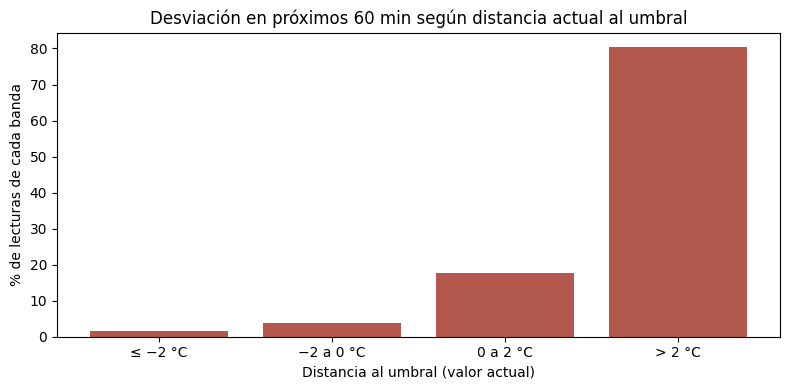

In [6]:
tel["timestamp_dt"]=pd.to_datetime(tel["timestamp_utc"],utc=True,errors="coerce")
serie=tel.sort_values(["viaje_id","timestamp_dt","fila_bronze"],kind="stable").copy()
g=serie.groupby("viaje_id",sort=False)
serie["temp_lag1_c"]=g["temp_c"].shift(1)
serie["timestamp_lag1"]=g["timestamp_dt"].shift(1)
serie["temp_lag1_observada"]=g["temperatura_observada"].shift(1).fillna(False).astype(bool)
serie["delta_min"]=(serie["timestamp_dt"]-serie["timestamp_lag1"]).dt.total_seconds()/60
serie["pendiente_c_30min"]=(serie["temp_c"]-serie["temp_lag1_c"])*30/serie["delta_min"]
serie["hora_bolivia"]=serie["timestamp_dt"].dt.tz_convert("America/La_Paz").dt.hour
elegible=(serie["lectura_termica_observada"] & serie["temp_lag1_observada"] &
          serie["delta_min"].eq(30) & serie["temp_lag1_c"].notna() & serie["flag_60min"].notna())
alerta=serie.loc[elegible,["viaje_id","timestamp_utc","hora_bolivia","temp_c","temp_lag1_c",
    "pendiente_c_30min","desvio_respecto_umbral_c","humedad_cabina_pct_tratada","flag_60min"]].copy()
alerta["humedad_pct"]=pd.to_numeric(alerta["humedad_cabina_pct_tratada"],errors="coerce")
alerta["banda_desvio_actual"]=pd.cut(alerta["desvio_respecto_umbral_c"],
    bins=[-np.inf,-2,0,2,np.inf],labels=["≤ −2 °C","−2 a 0 °C","0 a 2 °C","> 2 °C"],include_lowest=True)
tasas=alerta.groupby("banda_desvio_actual",observed=True).agg(
    lecturas=("flag_60min","size"),pct_desviacion_60min=("flag_60min",lambda s:100*s.mean())).reset_index()
print("Lecturas IoT:",len(tel),"| Lecturas elegibles con rezago de 30 min:",len(alerta))
print("Objetivos positivos en población elegible:",int(alerta["flag_60min"].sum()))
sin_desvio=alerta.loc[alerta["desvio_respecto_umbral_c"].le(0)]
print("Lecturas aún dentro de tolerancia:",len(sin_desvio),
      "| Positivos próximos 60 min:",int(sin_desvio["flag_60min"].sum()))
display(tasas.round(2))

if plt is not None:
    fig,ax=plt.subplots(figsize=(8,4))
    ax.bar(tasas["banda_desvio_actual"].astype(str),tasas["pct_desviacion_60min"],color="#b3584c")
    ax.set_title("Desviación en próximos 60 min según distancia actual al umbral")
    ax.set_ylabel("% de lecturas de cada banda");ax.set_xlabel("Distancia al umbral (valor actual)")
    fig.tight_layout();plt.show()


## 6. Lectura de resultados y límites

Este EDA no reemplaza una validación de negocio de umbrales inferidos ni una evaluación predictiva. Las poblaciones observadas excluyen imputaciones; por eso sus denominadores pueden diferir de los totales Silver. Las sumas de merma son **unidades registradas**, sin presentación física uniforme confirmada. El número de viajes puede variar respecto de 24 lecturas por viaje tras cuarentena. Para construir un modelo de 60 minutos habría que aplicar una separación temporal de entrenamiento/prueba, definir disponibilidad de variables en el momento de predicción y recalcular toda inferencia solo con los datos disponibles en entrenamiento.

Los CSV originales no se modifican. Las tablas y figuras se recalculan al ejecutar las celdas en orden.
